In [ ]:
import numpy as np
import os
import sys
import tkinter as tk
import tifffile
import src.utils.ingaas_processing as ingaas_processing
#import src.stitching.helpers as test
from src import stitching
from src.stitching import helpers
import cv2
from matplotlib import pyplot as plt
from tkinter import filedialog
import scipy
import toml_rs as tml
import io

root = tk.Tk()
root.withdraw()
root.call('wm', 'attributes', '.', '-topmost', True)

width, height = 640, 512

In [2]:
im_path = filedialog.askopenfilename(title='Select image to process')
cal_path = "data/calibration.npz"
K,P,DIM = ingaas_processing.load_calibration(cal_path)
images = tifffile.imread(im_path)
images_undistort = np.array(ingaas_processing.undistort(images, K, P, DIM))
vmin = np.min(images_undistort)
vmax = np.max(images_undistort)

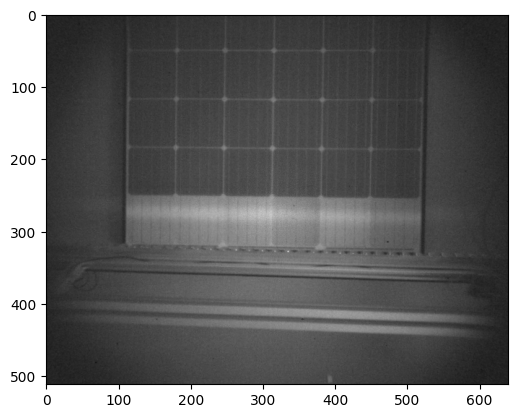

first_col 0
last_col 816


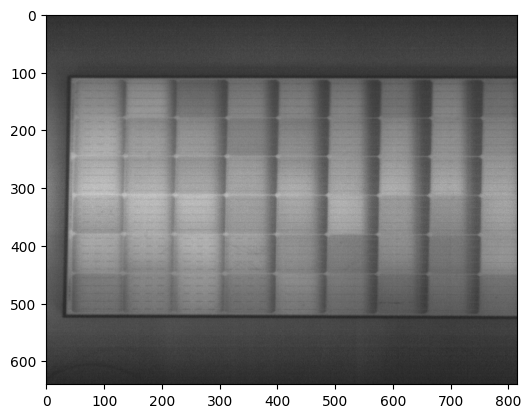

In [4]:
plt.imshow(images_undistort[200], cmap='gray', vmin=vmin, vmax=vmax)
plt.show()
stitch_no_rot = stitching.continuous(np.rot90(images_undistort, k=3, axes=(1,2)), 4000, 50)
plt.imshow(stitch_no_rot, cmap='gray', vmin=vmin, vmax=vmax)
plt.show()

In [5]:
rot_test_1 = scipy.ndimage.rotate(images_undistort, angle=1.491 ,axes=(1,2))
rot_test_2 = scipy.ndimage.rotate(images_undistort, angle=1.491 ,axes=(2,1))

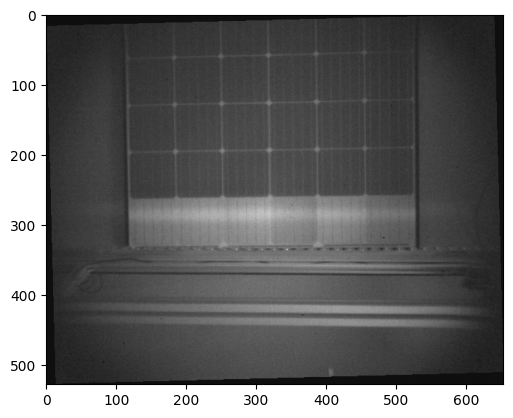

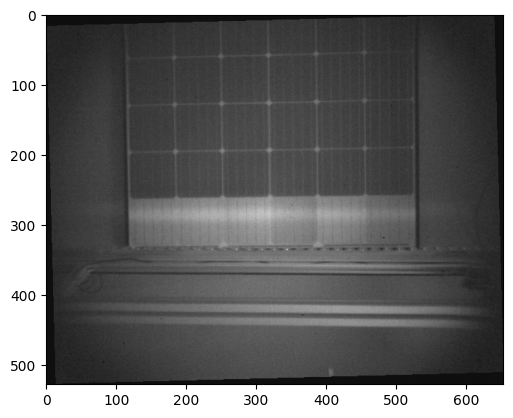

first_col 0
last_col 816


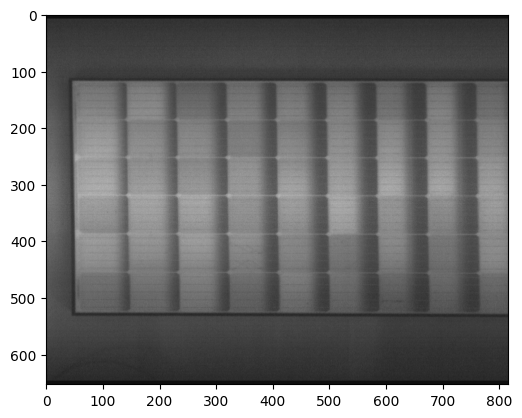

first_col 0
last_col 816


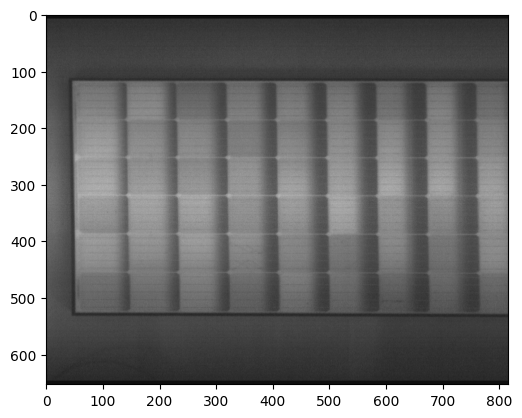

In [6]:
plt.imshow(rot_test_1[200], cmap='gray', vmin=vmin, vmax=vmax)
plt.show()
plt.imshow(rot_test_2[200], cmap='gray', vmin=vmin, vmax=vmax)
plt.show()
stitch_rot_1 = stitching.continuous(np.rot90(rot_test_1, k=3, axes=(1,2)), 4000, 50)
plt.imshow(stitch_rot_1, cmap='gray', vmin=vmin, vmax=vmax)
plt.show()
stitch_rot_2 = stitching.continuous(np.rot90(rot_test_2, k=3, axes=(1,2)), 4000, 50)
plt.imshow(stitch_rot_2, cmap='gray', vmin=vmin, vmax=vmax)
plt.show()

In [14]:
dpf = (4000 / 60) / 50
dpf_f = dpf / 1045 * 6
px_ratio_x = 15
dpf_px = dpf_f / (px_ratio_x / 1000)
test_arr = np.arange(len(images))
print(np.unique(np.int32(test_arr*dpf_px), return_counts=True)[1])

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 1 

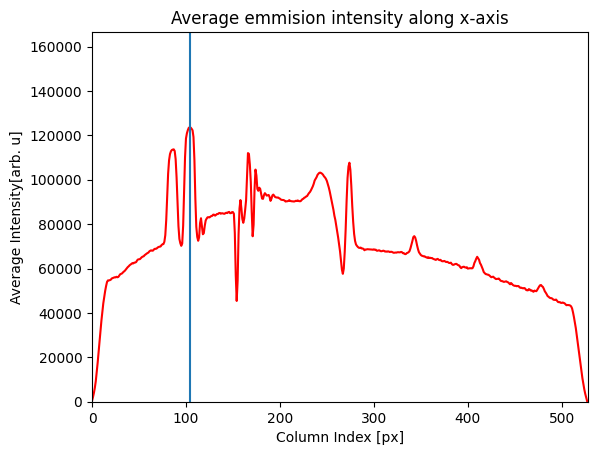

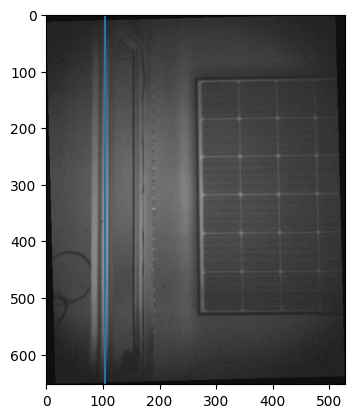

In [67]:
test_images = np.rot90(rot_test_1, k=3, axes=(1,2))
index = 0
peak_tests = helpers.peak_intensity(test_images[index], axis=0)
helpers.plot_intensity(test_images[index], axis=0, peak=True)
plt.imshow(test_images[index], cmap='gray', vmin=vmin, vmax=vmax)
plt.axvline(x=peak_tests)
plt.show()

In [10]:
config = {
    "gantry" : {
        "speed" : 5000
    },
    "camera" : {
        "resolution" : [640, 480],
        "fps" : 50,
        "tint" : 2,
    }
}

filename = "test.toml"
print(os.path.join(os.path.abspath("data"), filename))
#tml.dump(config, os.path.join(os.path.abspath("data"), filename))

C:\Users\jeppe\Desktop\Work Stuffs\LIPI-scanner\LIPI-Processing\data\test.toml


In [6]:
import tomlkit
config_file = tomlkit.document()
config_file.add("title", "Default Config")

gantry = tomlkit.table()
gantry.add("speed", 5000)
config_file.add("gantry", gantry)

camera = tomlkit.table()
camera.add("fps", 50)
camera.add("tint", 2)
camera.add("gain", "medium")
config_file.add("camera", camera)

with open("data/test.toml", "w") as f:
    tomlkit.dump(config_file, f)

In [ ]:
test_dict = {"var1": 2, "var2": 3, "var3": 4}
test_dict2 = {"var1": }